# ARTI308 - Machine Learning

# Assignment: Exploratory Data Analysis (EDA)

## Chocolate Sales Dataset

This notebook applies the EDA techniques from Lab 3 to the **Chocolate Sales** dataset. The analysis focuses on understanding the data, checking data quality, exploring distributions and relationships, and identifying time-based sales patterns.

### Objectives
- Inspect the dataset structure and data types
- Check missing values and duplicate records
- Clean the date and revenue columns
- Generate descriptive statistics
- Perform univariate analysis
- Perform bivariate analysis
- Examine the relationship between boxes shipped and revenue
- Calculate correlations
- Analyze monthly revenue trends

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("Chocolate_Sales.csv")

print("Dataset loaded successfully.")
df.head(7)

Dataset loaded successfully.


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,NaN,Mint Chip Choco,04-01-2022,"$5,320.00",180
1,Jehu Rudeforth,UK,Mint Chip Choco,04-01-2022,"$5,320.00",180
2,Van Tuxwell,India,85% Dark Bars,01-08-2022,"$7,896.00",94
3,Gigi Bohling,India,Peanut Butter Cubes,07-07-2022,"$4,501.00",91
4,Jan Morforth,Australia,Peanut Butter Cubes,27-04-2022,"$12,726.00",342
5,Jehu Rudeforth,UK,Peanut Butter Cubes,24-02-2022,"$13,685.00",184
6,Van Tuxwell,India,Smooth Sliky Salty,06-06-2022,"$5,376.00",38


The dataset contains individual chocolate sales transactions. Each row represents a sales transaction, with information about the salesperson, country, product, date, amount, and number of boxes shipped.

## 3. Inspect the Data Types

In [3]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,object
Amount,object
Boxes Shipped,int64


The initial inspection shows that `Date` and `Amount` are stored as object/text values. Since date analysis and numerical calculations require appropriate data types, these columns need to be converted.

## 4. Data Cleaning and Type Conversion

In [4]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

df["Amount"] = df["Amount"].replace(r"[\$,]", "", regex=True)
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

print(df.dtypes)

Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object


After conversion, `Date` is a datetime column and `Amount` is numeric. This makes it possible to calculate revenue statistics and perform time-based analysis reliably.

## 5. Check Missing Values

In [5]:
missing_values = df.isna().sum()
print(missing_values)

Sales Person     0
Country          1
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


The missing-value check identifies whether any columns contain incomplete records. Missing values should be considered before aggregation or modeling because they can affect results.

## 6. Check Duplicate Rows

In [6]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)])

Number of duplicate rows: 1


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
13,Mallorie Waber,Canada,Eclairs,2022-01-13,1442.0,286
14,Mallorie Waber,Canada,Eclairs,2022-01-13,1442.0,286


Duplicate rows can cause the same transaction to be counted more than once. The duplicate records are therefore identified before continuing with the analysis.

## 7. Handle Data Quality Issues

In [7]:
df = df.drop_duplicates().copy()

df["Country"] = df["Country"].fillna("Unknown")

print("Shape after cleaning:", df.shape)
print("Missing values after cleaning:")
print(df.isna().sum())

Shape after cleaning: (3283, 6)
Missing values after cleaning:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


One exact duplicate row is removed. The single missing country value is replaced with `Unknown` so that the sales transaction remains available for analysis without inventing a country.

## 8. Number of Rows and Columns

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 3283
Number of columns: 6


The cleaned dataset contains the remaining unique sales transactions and the original six variables.

## 9. Descriptive Summary Statistics

In [9]:
df.describe(include="all")

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
count,3283,3283,3283,3283,3283.000000,3283.000000
unique,25,7,22,NaN,NaN,NaN
top,Kelci Walkden,Australia,Eclairs,NaN,NaN,NaN
freq,162,615,180,NaN,NaN,NaN
mean,NaN,NaN,NaN,2023-05-03 11:36:32.019494400,6030.122406,164.671642
min,NaN,NaN,NaN,2022-01-03 00:00:00,7.000000,1.000000
25%,NaN,NaN,NaN,2022-07-04 00:00:00,2522.990000,71.000000
50%,NaN,NaN,NaN,2023-05-11 00:00:00,5229.000000,137.000000
75%,NaN,NaN,NaN,2024-03-02 00:00:00,8555.095000,232.000000
max,NaN,NaN,NaN,2024-08-31 00:00:00,26170.950000,778.000000


The descriptive statistics summarize the numerical variables, including the center, spread, minimum, and maximum values. The categorical columns show their number of unique values and most frequent categories.

## 10. Univariate Analysis

### Distribution of Boxes Shipped

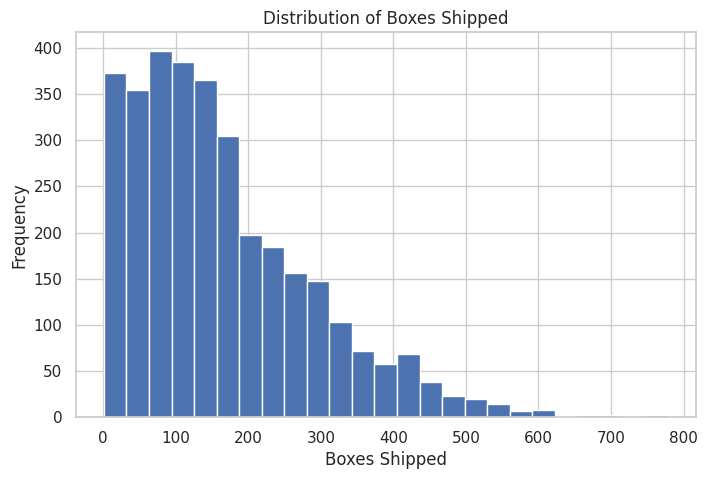

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["Boxes Shipped"], bins=25)
plt.title("Distribution of Boxes Shipped")
plt.xlabel("Boxes Shipped")
plt.ylabel("Frequency")
plt.show()

The distribution of boxes shipped is right-skewed: many transactions involve relatively smaller shipments, while fewer transactions contain a large number of boxes.

### Distribution of Revenue

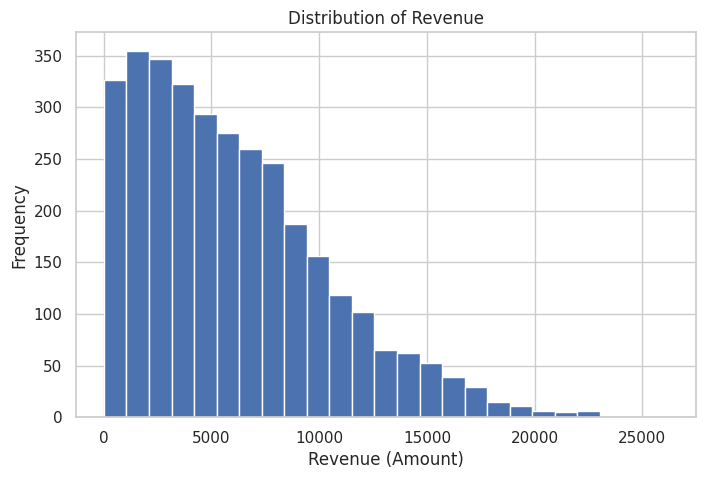

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["Amount"], bins=25)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue (Amount)")
plt.ylabel("Frequency")
plt.show()

Revenue is also right-skewed. Most transactions generate moderate revenue, while a smaller number of transactions have substantially higher revenue.

### Outlier Inspection

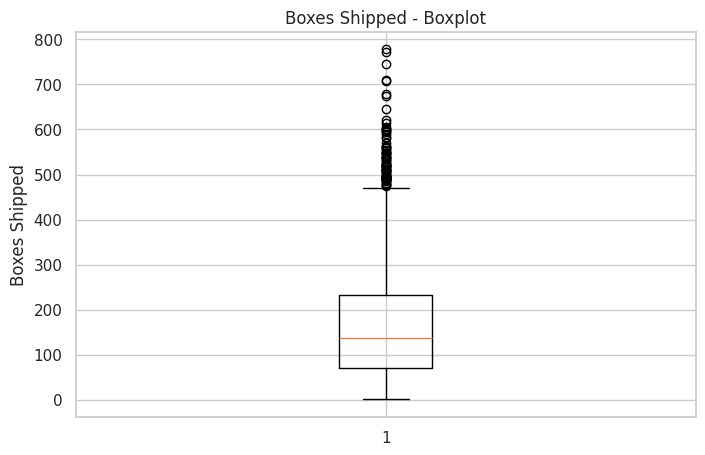

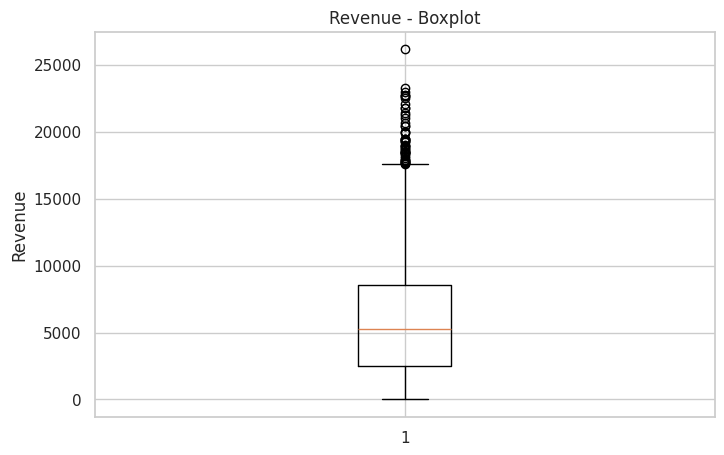

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Boxes Shipped"], vert=True)
plt.title("Boxes Shipped - Boxplot")
plt.ylabel("Boxes Shipped")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df["Amount"], vert=True)
plt.title("Revenue - Boxplot")
plt.ylabel("Revenue")
plt.show()

The boxplots show that both shipment volume and revenue contain high-value observations. These observations are not automatically errors; they may represent genuinely large sales transactions and should be investigated rather than removed without justification.

## 11. Bivariate Analysis

### Revenue by Country

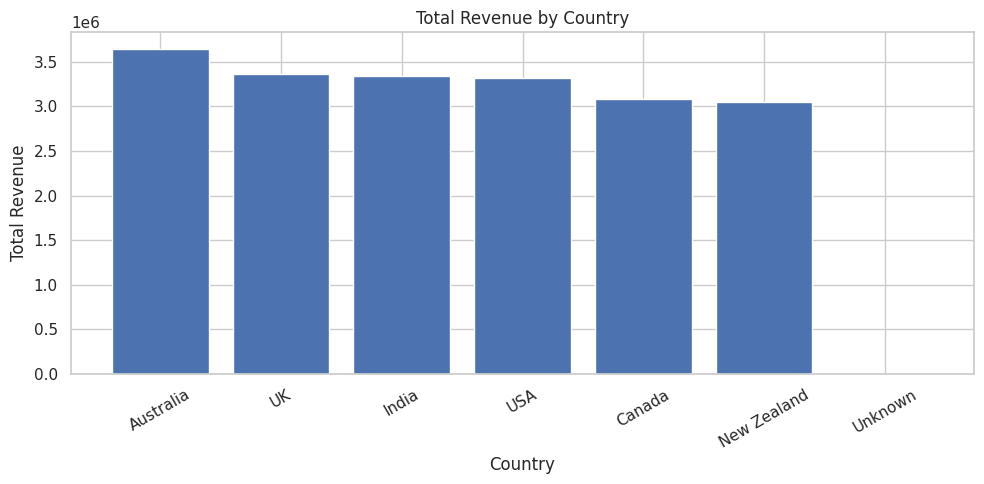

,Amount
Country,
Australia,3646444.35
UK,3365388.90
India,3343730.83
USA,3313858.09
Canada,3078495.65
New Zealand,3043654.04
Unknown,5320.00


In [13]:
country_revenue = df.groupby("Country")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(country_revenue.index, country_revenue.values)
plt.title("Total Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

country_revenue

Total revenue differs across countries, showing geographical differences in sales performance. The `Unknown` category represents the transaction whose country was missing in the original data.

### Revenue by Product

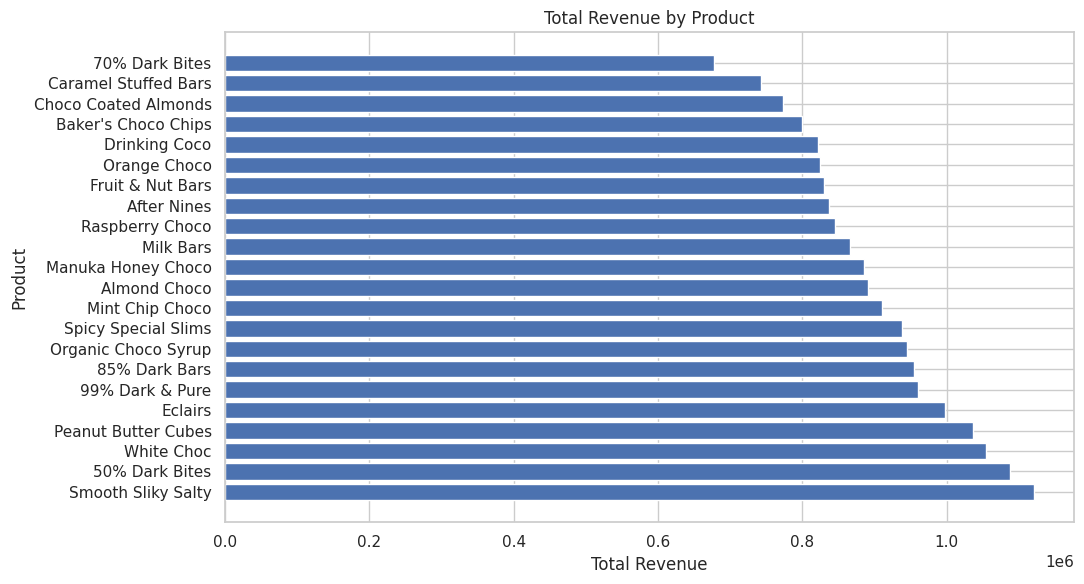

,Amount
Product,
Smooth Sliky Salty,1120201.09
50% Dark Bites,1087659.35
White Choc,1054257.00
Peanut Butter Cubes,1036591.09
Eclairs,996947.96
99% Dark & Pure,960033.45
85% Dark Bars,955268.24
Organic Choco Syrup,945345.73
Spicy Special Slims,938131.69


In [14]:
product_revenue = df.groupby("Product")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(11, 6))
plt.barh(product_revenue.index, product_revenue.values)
plt.title("Total Revenue by Product")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

product_revenue

Revenue varies across chocolate products. This indicates that product type is associated with differences in total sales revenue.

### Revenue by Sales Person

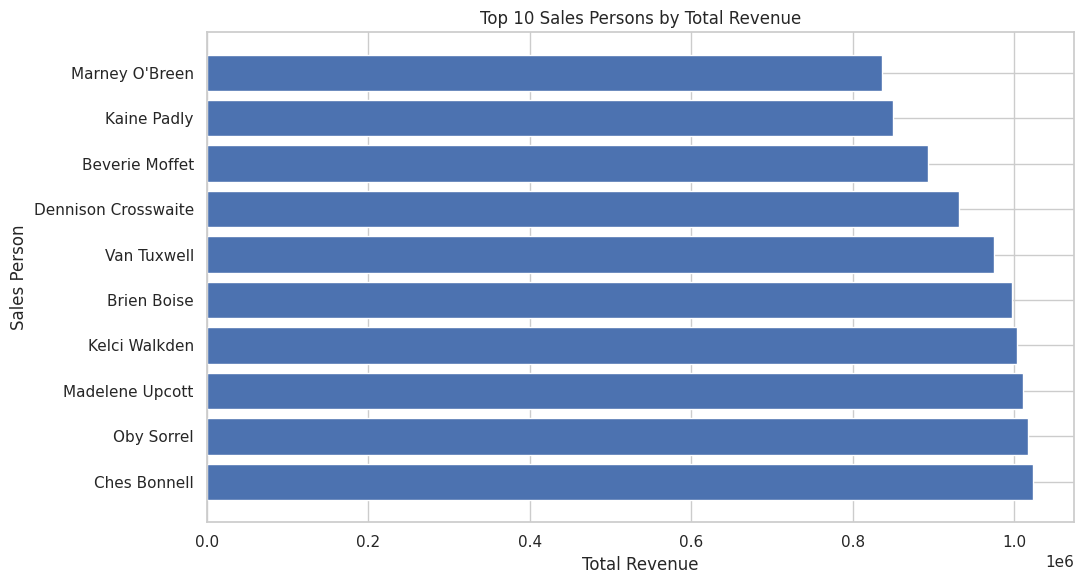

,Amount
Sales Person,
Ches Bonnell,1022599.96
Oby Sorrel,1017204.12
Madelene Upcott,1010028.72
Kelci Walkden,1002929.10
Brien Boise,997326.48
Van Tuxwell,974425.09
Dennison Crosswaite,931849.57
Beverie Moffet,892421.37
Kaine Padly,849062.76


In [15]:
salesperson_revenue = df.groupby("Sales Person")["Amount"].sum().sort_values(ascending=False)

top_salespeople = salesperson_revenue.head(10)
plt.figure(figsize=(11, 6))
plt.barh(top_salespeople.index, top_salespeople.values)
plt.title("Top 10 Sales Persons by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Sales Person")
plt.tight_layout()
plt.show()

salesperson_revenue.head(10)

The total revenue contribution varies among salespersons. A smaller group of salespersons accounts for higher total revenue, although the analysis alone does not establish why these differences occur.

## 12. Boxes Shipped vs Revenue Relationship

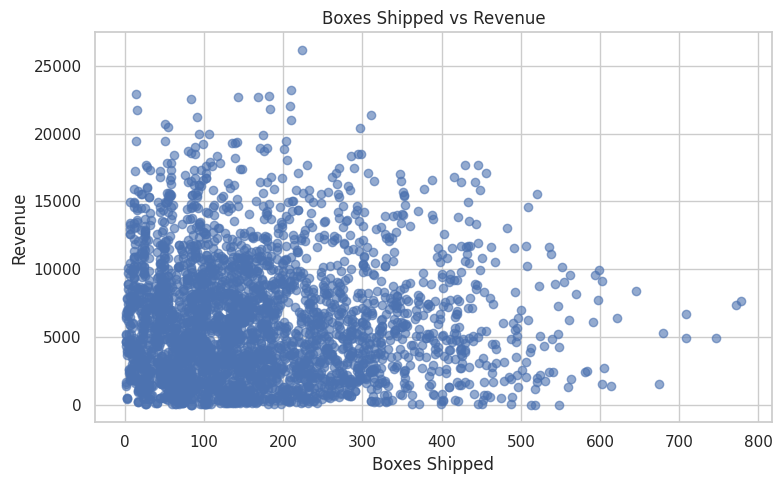

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Boxes Shipped"], df["Amount"], alpha=0.6)
plt.title("Boxes Shipped vs Revenue")
plt.xlabel("Boxes Shipped")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

The scatter plot shows a positive relationship between boxes shipped and revenue: transactions with more boxes often have higher revenue. However, there is considerable variation, indicating that shipment volume is not the only factor associated with revenue.

## 13. Correlation Matrix

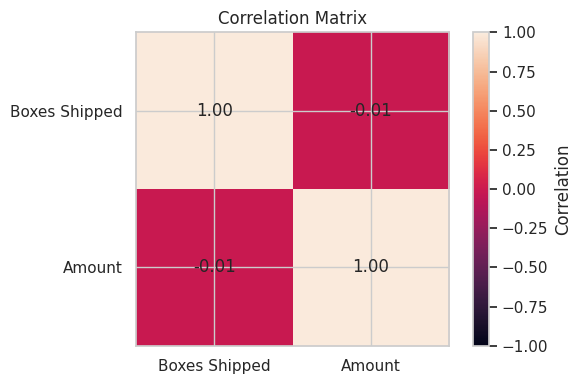

,Boxes Shipped,Amount
Boxes Shipped,1.00000,-0.01316
Amount,-0.01316,1.00000


In [17]:
numeric_corr = df[["Boxes Shipped", "Amount"]].corr()

plt.figure(figsize=(6, 4))
plt.imshow(numeric_corr, vmin=-1, vmax=1)
plt.xticks(range(len(numeric_corr.columns)), numeric_corr.columns)
plt.yticks(range(len(numeric_corr.index)), numeric_corr.index)
for i in range(len(numeric_corr.index)):
    for j in range(len(numeric_corr.columns)):
        plt.text(j, i, f"{numeric_corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Correlation Matrix")
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

numeric_corr

The correlation coefficient summarizes the linear relationship between boxes shipped and revenue. A positive value indicates that the two variables tend to increase together, but correlation does not by itself establish causation.

## 14. Time-Based Analysis

### Monthly Revenue Trend

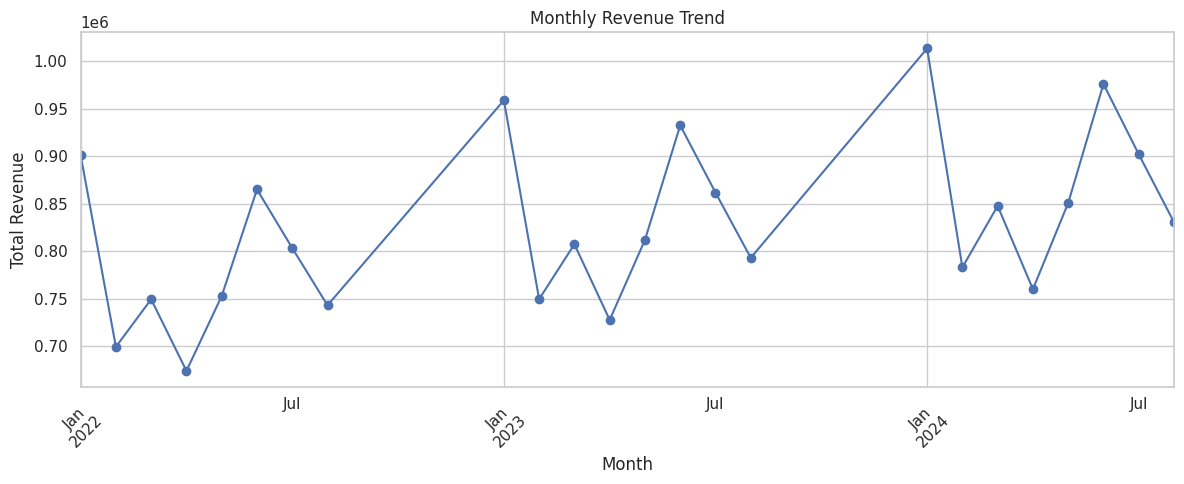

,Amount
Month,
2022-01,901425.00
2022-02,699377.00
2022-03,749483.00
2022-04,674051.00
2022-05,752892.00
2022-06,865144.00
2022-07,803425.00
2022-08,743148.00
2023-01,958985.77


In [18]:
df["Month"] = df["Date"].dt.to_period("M")
monthly_revenue = df.groupby("Month")["Amount"].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_revenue

Monthly revenue changes over time, showing fluctuations in sales activity. These changes may indicate periodic or seasonal variation and provide a useful basis for further time-series analysis.

## 15. Key EDA Findings

- The dataset contains sales transactions described by salesperson, country, product, date, revenue amount, and boxes shipped.
- `Date` and `Amount` required type conversion before analysis.
- The original data contained one missing country value and one duplicate row; these were handled during cleaning.
- Boxes shipped and revenue are both right-skewed, with high-value observations visible in the boxplots.
- Total revenue varies across countries, products, and salespersons.
- Boxes shipped and revenue show a positive relationship, although there is noticeable variation between transactions.
- Monthly revenue fluctuates over time, making the date variable useful for time-based analysis.

### Conclusion
EDA provides an initial understanding of the Chocolate Sales dataset and highlights data-quality issues, distributions, relationships, and time patterns that should be considered before applying machine-learning models.